# **패션 MNIST 데이터에 대한 CNN 모델**

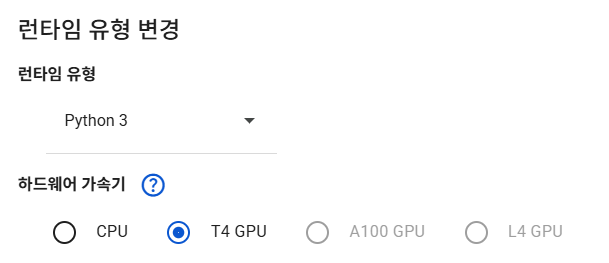

In [ ]:
!pip install koreanize_matplotlib; import seaborn as sns
import koreanize_matplotlib
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 53.5 MB/s eta 0:00:00
/bin/bash: line 1: import: command not found


데이터 불러오기(Fashion MNIST)

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test)=fashion_mnist.load_data()

print("훈련용 이미지의 차원 =", x_train.shape)
print("검증용 이미지의 차원 =", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련용 이미지의 차원 = (60000, 28, 28)
검증용 이미지의 차원 = (10000, 28, 28)


Conv2D 레이어는 입력 이미지가 3차원이어야 합니다.
* 따라서 (28, 28) 2차원을 (28,28,1)로 reshape 해야합니다.

In [ ]:
x_train=x_train.reshape(60000, 28, 28, 1)
x_test=x_test.reshape(10000, 28, 28, 1)

print("훈련용 이미지의 차원 =", x_train.shape)
print("훈련용 라벨의 차원 =", y_test.shape)
print("검증용 이미지의 차원 =", x_test.shape)
print("검증용 라벨의 차원 =", y_test.shape)

훈련용 이미지의 차원 = (60000, 28, 28, 1)
훈련용 라벨의 차원 = (10000,)
검증용 이미지의 차원 = (10000, 28, 28, 1)
검증용 라벨의 차원 = (10000,)


In [ ]:
x_train=x_train/255; x_test=x_test/255   # 이미지 데이터 정규화
class_labels=["Top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Boot"]

In [ ]:
# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

model=Sequential([
    Input(shape=(28,28,1)),
# Block 1
    Conv2D(32, (3,3), padding='same', activation='elu'),
    Conv2D(32, (3,3), padding='same', activation='elu'),
    MaxPooling2D(),
    Dropout(0.2),
# Block 2
    Conv2D(64, (3,3), padding='same', activation='elu'),
    Conv2D(64, (3,3), padding='same', activation='elu'),
    MaxPooling2D(),
    Dropout(0.3),
# Block 3
    Conv2D(128, (3,3), padding='same', activation='elu'),
    MaxPooling2D(),
    Dropout(0.4),
# Dense 층으로 연결
    GlobalAveragePooling2D(),
    Dense(64, activation='elu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
    ])

early_stop=EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True )
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history=model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, callbacks=[early_stop])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7431 - loss: 0.7046 - val_accuracy: 0.8553 - val_loss: 0.3951
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8389 - loss: 0.4498 - val_accuracy: 0.8714 - val_loss: 0.3438
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8620 - loss: 0.3883 - val_accuracy: 0.8831 - val_loss: 0.3144
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8734 - loss: 0.3543 - val_accuracy: 0.9013 - val_loss: 0.2763
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8816 - loss: 0.3323 - val_accuracy: 0.8947 - val_loss: 0.2992
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8854 - loss: 0.3187 - val_accuracy: 0.9034 - val_loss: 0.2632
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8924 - loss: 0.3034 - val_accuracy: 0.9081 - val_loss: 0.2545
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8968 - loss: 

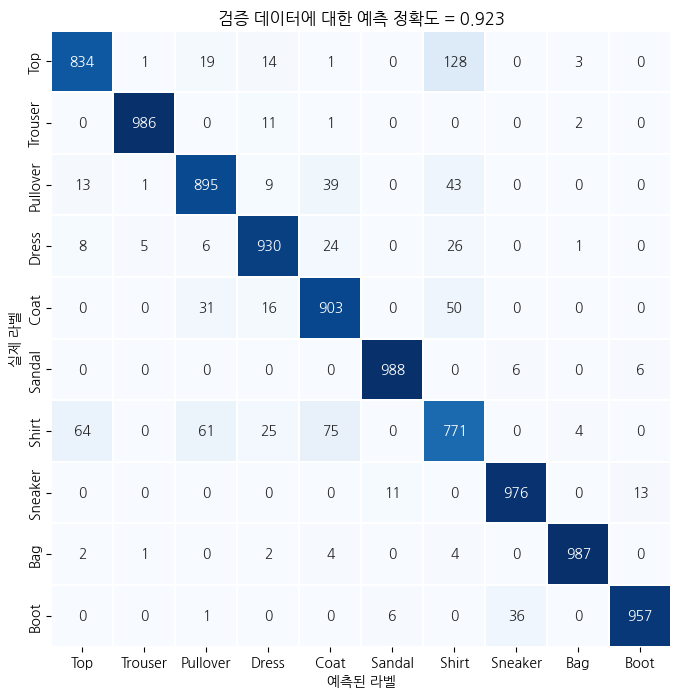

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

y_prob=model.predict(x_test, verbose=0)  # 클래스별 확률 예측
y_pred=np.argmax(y_prob, axis=1)  # max 확률 인덱스

# 검증용 데이터셋에 대한 혼동행렬 생성
cm=confusion_matrix(y_test, y_pred)
# 분류 정확도 계산
acc=accuracy_score(y_test, y_pred)

# 혼동행렬 시각화 (이전 코드 재활용)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True,fmt="d", linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)

plt.ylabel('실제 라벨'); plt.xlabel('예측된 라벨')
plt.title(f"검증 데이터에 대한 예측 정확도 = {acc:.3f}")
plt.show()

### 블록의 수, 하이퍼파라미터(필터 수, 필터 크기, 드롭아웃 비율 등 등)를 변경하여 예측력을 더욱 높일 수 있습니다.